In [1]:
from cProfile import label

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
label_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.pkl")
label_df.rename(columns = {"m6A_level": "dom_label"}, inplace = True)

In [3]:
print(label_df["label"].value_counts())

label
 0    7491694
-3    5290375
-1     431206
 1      34513
Name: count, dtype: int64


In [5]:
dorado_alt = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
dorado_alt.rename(columns = {"dom": "pred_dorado", "count_dom": "dorado_count"}, inplace = True)
dorado_alt = dorado_alt[["pred_dorado", "dorado_count", "genome_id"]]
print(dorado_alt)

                 pred_dorado  dorado_count        genome_id
genome_id                                                  
chr10:+:1000680     0.142857             7  chr10:+:1000680
chr10:+:1000681     0.004219           474  chr10:+:1000681
chr10:+:1000683     0.004073           491  chr10:+:1000683
chr10:+:1000685     0.017167           466  chr10:+:1000685
chr10:+:1000688     1.000000             1  chr10:+:1000688
...                      ...           ...              ...
chrX:-:9760794      0.000000             5   chrX:-:9760794
chrX:-:9760797      0.000000             5   chrX:-:9760797
chrX:-:9760808      0.250000             4   chrX:-:9760808
chrX:-:9760817      0.000000             5   chrX:-:9760817
chrX:-:9760823      0.000000             4   chrX:-:9760823

[22959784 rows x 3 columns]


In [ ]:
airna_alt = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/hek293t.pileup.genomic.pkl"
airna_alt = pd.read_pickle(airna_alt)
print(airna_alt)

In [4]:
m6anet_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/out/genomic/gene_df_final.pkl")
m6anet_df.rename(columns = { "pm6a": "pred_m6anet", "dom": "dom_m6anet", "count_pm6a": "count_m6anet"}, inplace = True)
m6anet_df = m6anet_df[["genome_id", "pred_m6anet", "dom_m6anet", "count_m6anet"]]
print(m6anet_df)

FileNotFoundError: [Errno 2] No such file or directory: '/extdata4/baeklab/Hyeonseo/m6A/m6anet/ON0090/out/genomic/gene_df_final.pkl'

In [6]:
airna_alt.reset_index(inplace=True, drop=True)
dorado_alt.reset_index(inplace=True, drop=True)
m6anet_df.reset_index(inplace=True, drop=True)


In [7]:
airna_alt_d20 = airna_alt[airna_alt["count_all"] >= 20]
dorado_alt_d20 = dorado_alt[dorado_alt["dorado_count"] >= 20]
m6anet_df_d20 = m6anet_df[m6anet_df["count_m6anet"] >= 20]

In [8]:
logsum_alt = airna_alt_d20.merge(dorado_alt_d20, on="genome_id", how="outer")
logsum_alt = logsum_alt.merge(m6anet_df_d20, on="genome_id", how="outer")
print(logsum_alt)

                 genome_id gene_symbol coding  isoforms      pm6a       dom  \
0          chr10:+:1000681      GTPBP4   True       1.0  0.009356  0.005340   
1          chr10:+:1000683      GTPBP4   True       1.0 -0.000000  0.005827   
2          chr10:+:1000685      GTPBP4   True       1.0  0.007684  0.009477   
3          chr10:+:1000694      GTPBP4   True       1.0 -0.000000  0.005283   
4          chr10:+:1000701      GTPBP4   True       1.0  0.007402  0.007397   
...                    ...         ...    ...       ...       ...       ...   
10881482   chrX:+:85074326         NaN    NaN       NaN       NaN       NaN   
10881483  chrX:-:119617148         NaN    NaN       NaN       NaN       NaN   
10881484  chrX:-:130063960         NaN    NaN       NaN       NaN       NaN   
10881485  chrX:-:154484548         NaN    NaN       NaN       NaN       NaN   
10881486   chrX:-:80676343         NaN    NaN       NaN       NaN       NaN   

          count_all  pred_dorado  dorado_count  pre

In [9]:
logsum_alt = logsum_alt[[ "genome_id", "pm6a", "dom", "count_all", "pred_dorado", "dorado_count","pred_m6anet", "dom_m6anet"]].copy()
logsum_alt = logsum_alt.merge(label_df, on="genome_id", how="right")
logsum_alt = logsum_alt.fillna(0)
print(logsum_alt)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681  0.009356  0.005340      482.0     0.004219   
1         chr10:+:1000683 -0.000000  0.005827      488.0     0.004073   
2         chr10:+:1000685  0.007684  0.009477      488.0     0.017167   
3         chr10:+:1000694 -0.000000  0.005283      496.0     0.006061   
4         chr10:+:1000701  0.007402  0.007397      486.0     0.002092   
...                   ...       ...       ...        ...          ...   
13247783   chrX:-:9760794  0.000000  0.000000        0.0     0.000000   
13247784   chrX:-:9760797  0.000000  0.000000        0.0     0.000000   
13247785   chrX:-:9760808  0.000000  0.000000        0.0     0.000000   
13247786   chrX:-:9760817  0.000000  0.000000        0.0     0.000000   
13247787   chrX:-:9760823  0.000000  0.000000        0.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                474.0     0.000000    0.000000

In [10]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

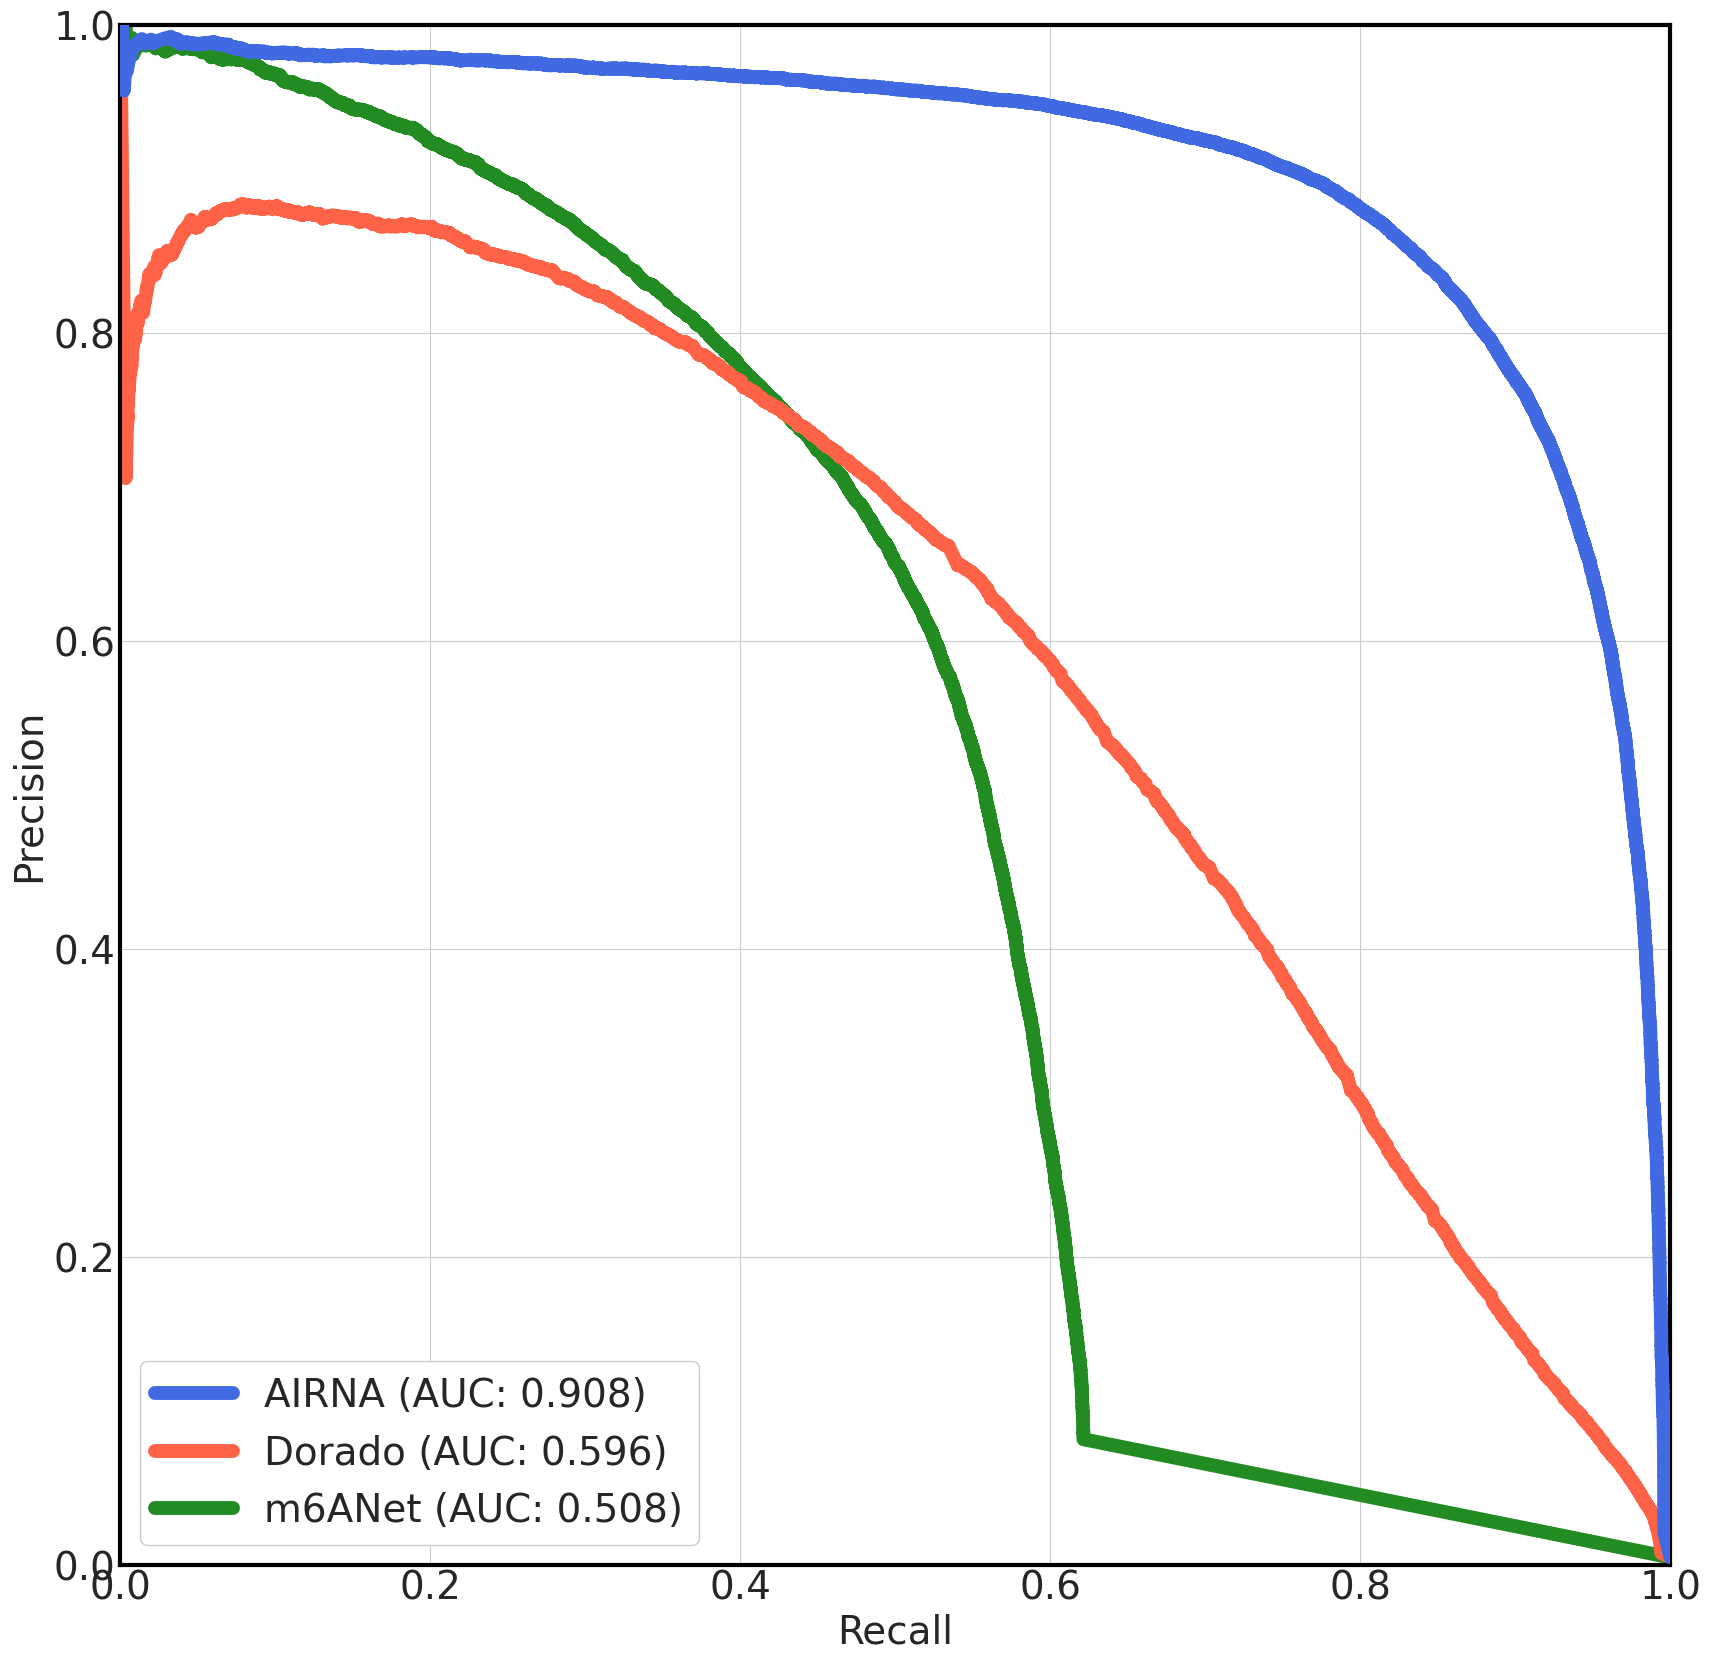

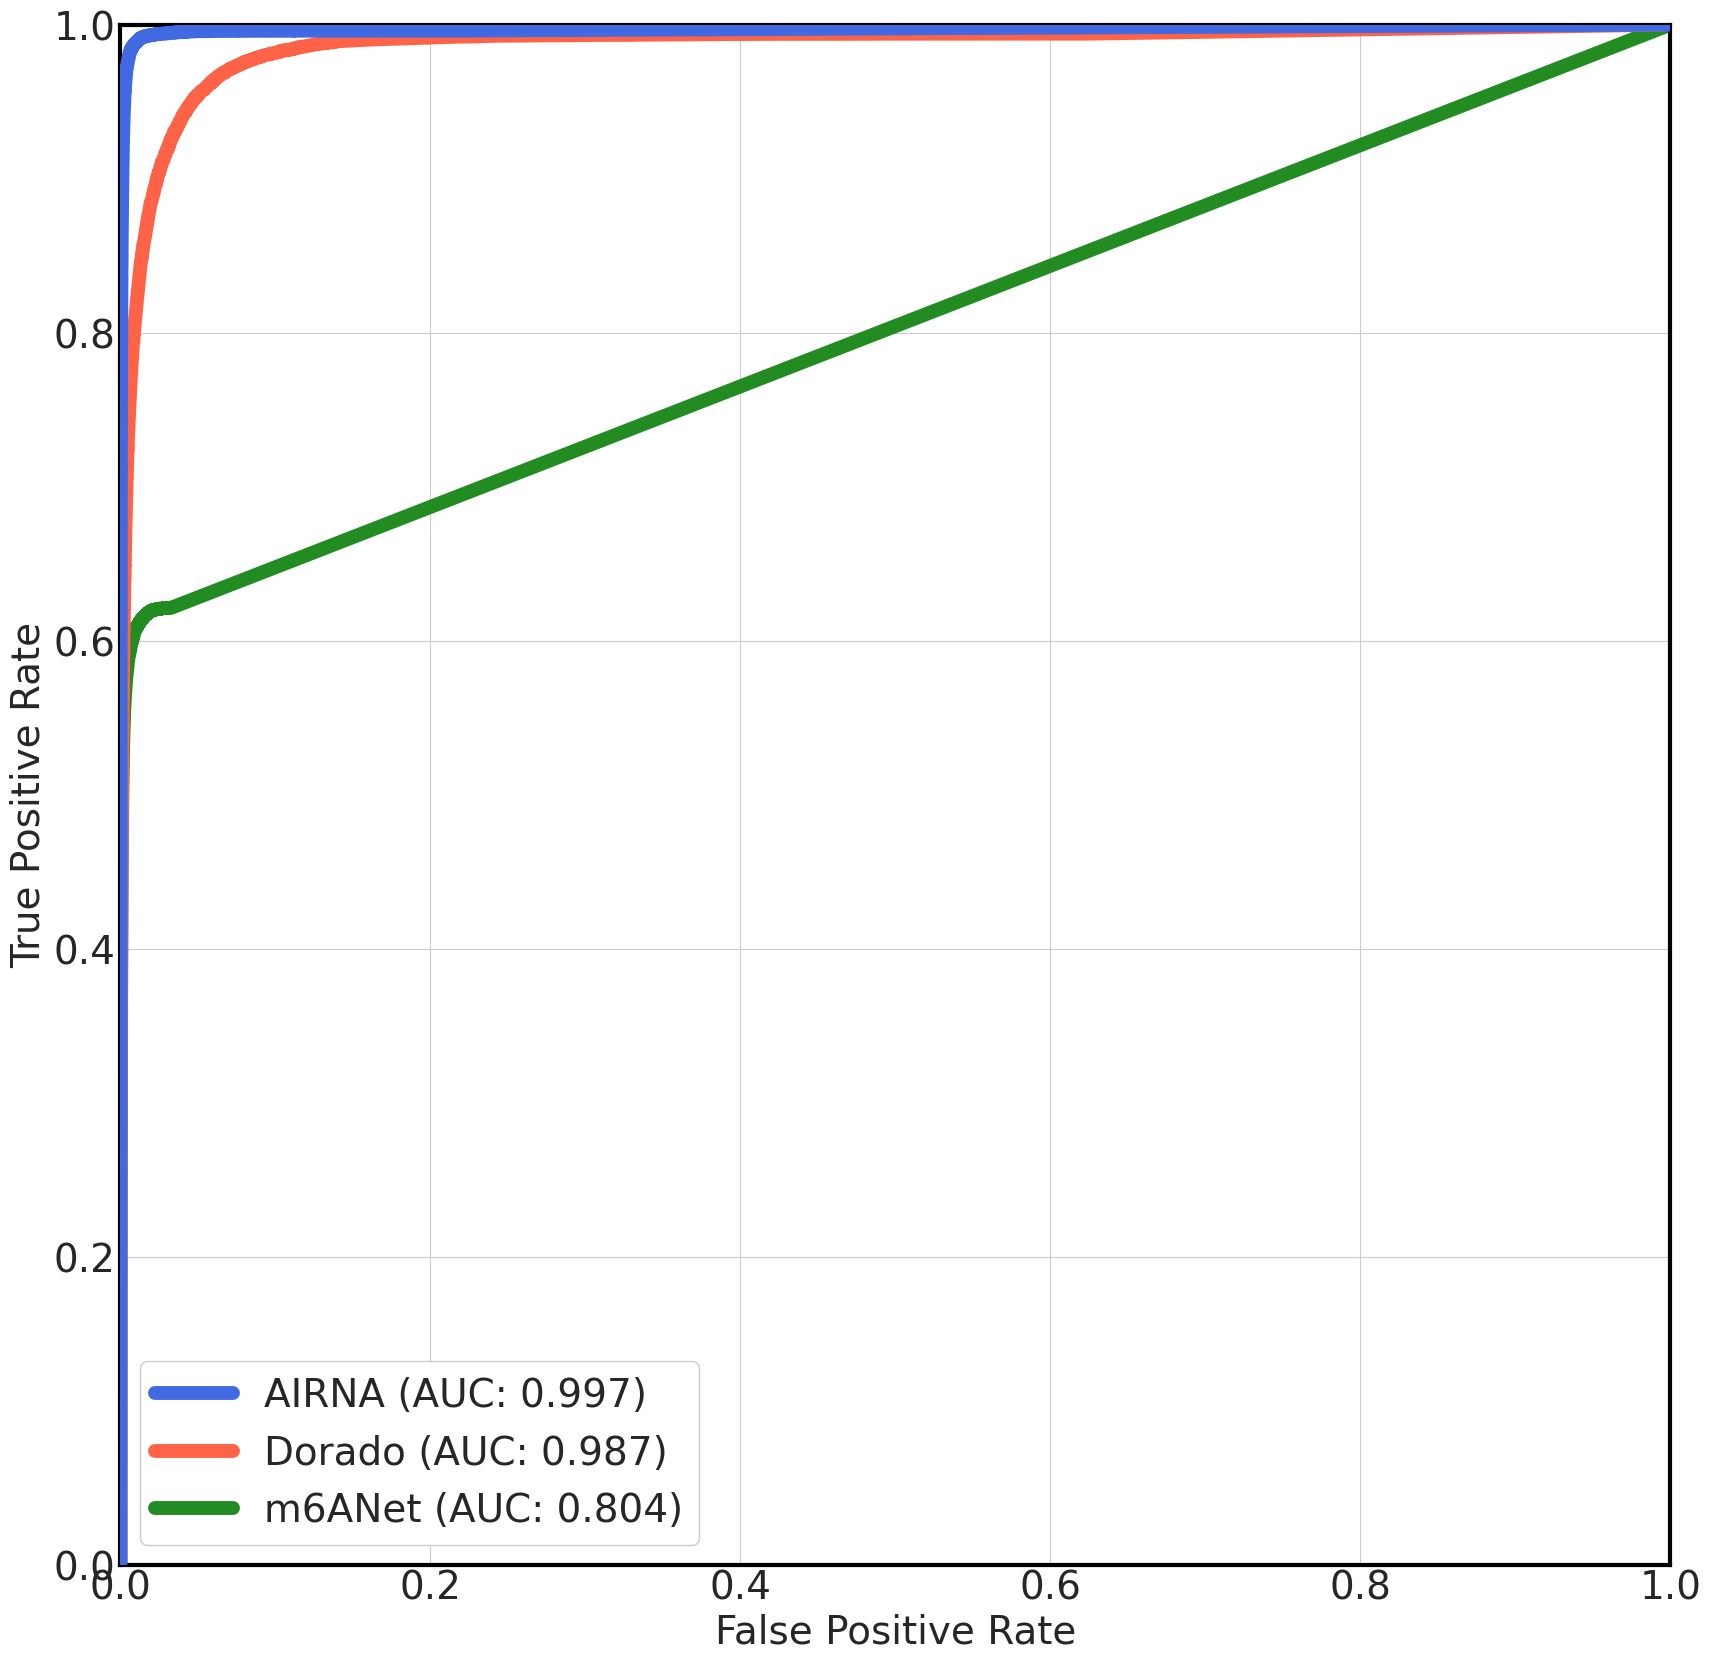

In [11]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

## Plot PR
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_roc.pdf", format="pdf")
plt.show()


In [12]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
print(selected_df)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681  0.009356  0.005340      482.0     0.004219   
1         chr10:+:1000683 -0.000000  0.005827      488.0     0.004073   
2         chr10:+:1000685  0.007684  0.009477      488.0     0.017167   
4         chr10:+:1000701  0.007402  0.007397      486.0     0.002092   
5         chr10:+:1000704  0.008293  0.012421      492.0     0.036957   
...                   ...       ...       ...        ...          ...   
13247521  chrX:-:86047490  0.000000  0.000000       20.0     0.000000   
13247523  chrX:-:86047493  0.000000  0.000000       21.0     0.000000   
13247524  chrX:-:86047498  0.000000  0.000000       21.0     0.000000   
13247526  chrX:-:86047509  0.000000  0.000000       20.0     0.000000   
13247527  chrX:-:86047522  0.000000  0.000000        0.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                474.0     0.000000    0.000000

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681  0.009356  0.005340      482.0     0.004219   
2         chr10:+:1000685  0.007684  0.009477      488.0     0.017167   
5         chr10:+:1000704  0.008293  0.012421      492.0     0.036957   
6         chr10:+:1000713 -0.000000  0.000892      492.0     0.010183   
7         chr10:+:1000716 -0.000000  0.002742      497.0     0.000000   
...                   ...       ...       ...        ...          ...   
13231569  chrX:-:77574324 -0.000000  0.015599       98.0     0.123457   
13231570  chrX:-:77574327  0.000000  0.000000       99.0     0.011494   
13231572  chrX:-:77574334  0.062143  0.012380       97.0     0.022727   
13231574  chrX:-:77574337  0.000000  0.000000       99.0     0.042553   
13231575  chrX:-:77574338 -0.000000  0.010928       99.0     0.011364   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
0                474.0          0.0         0.0

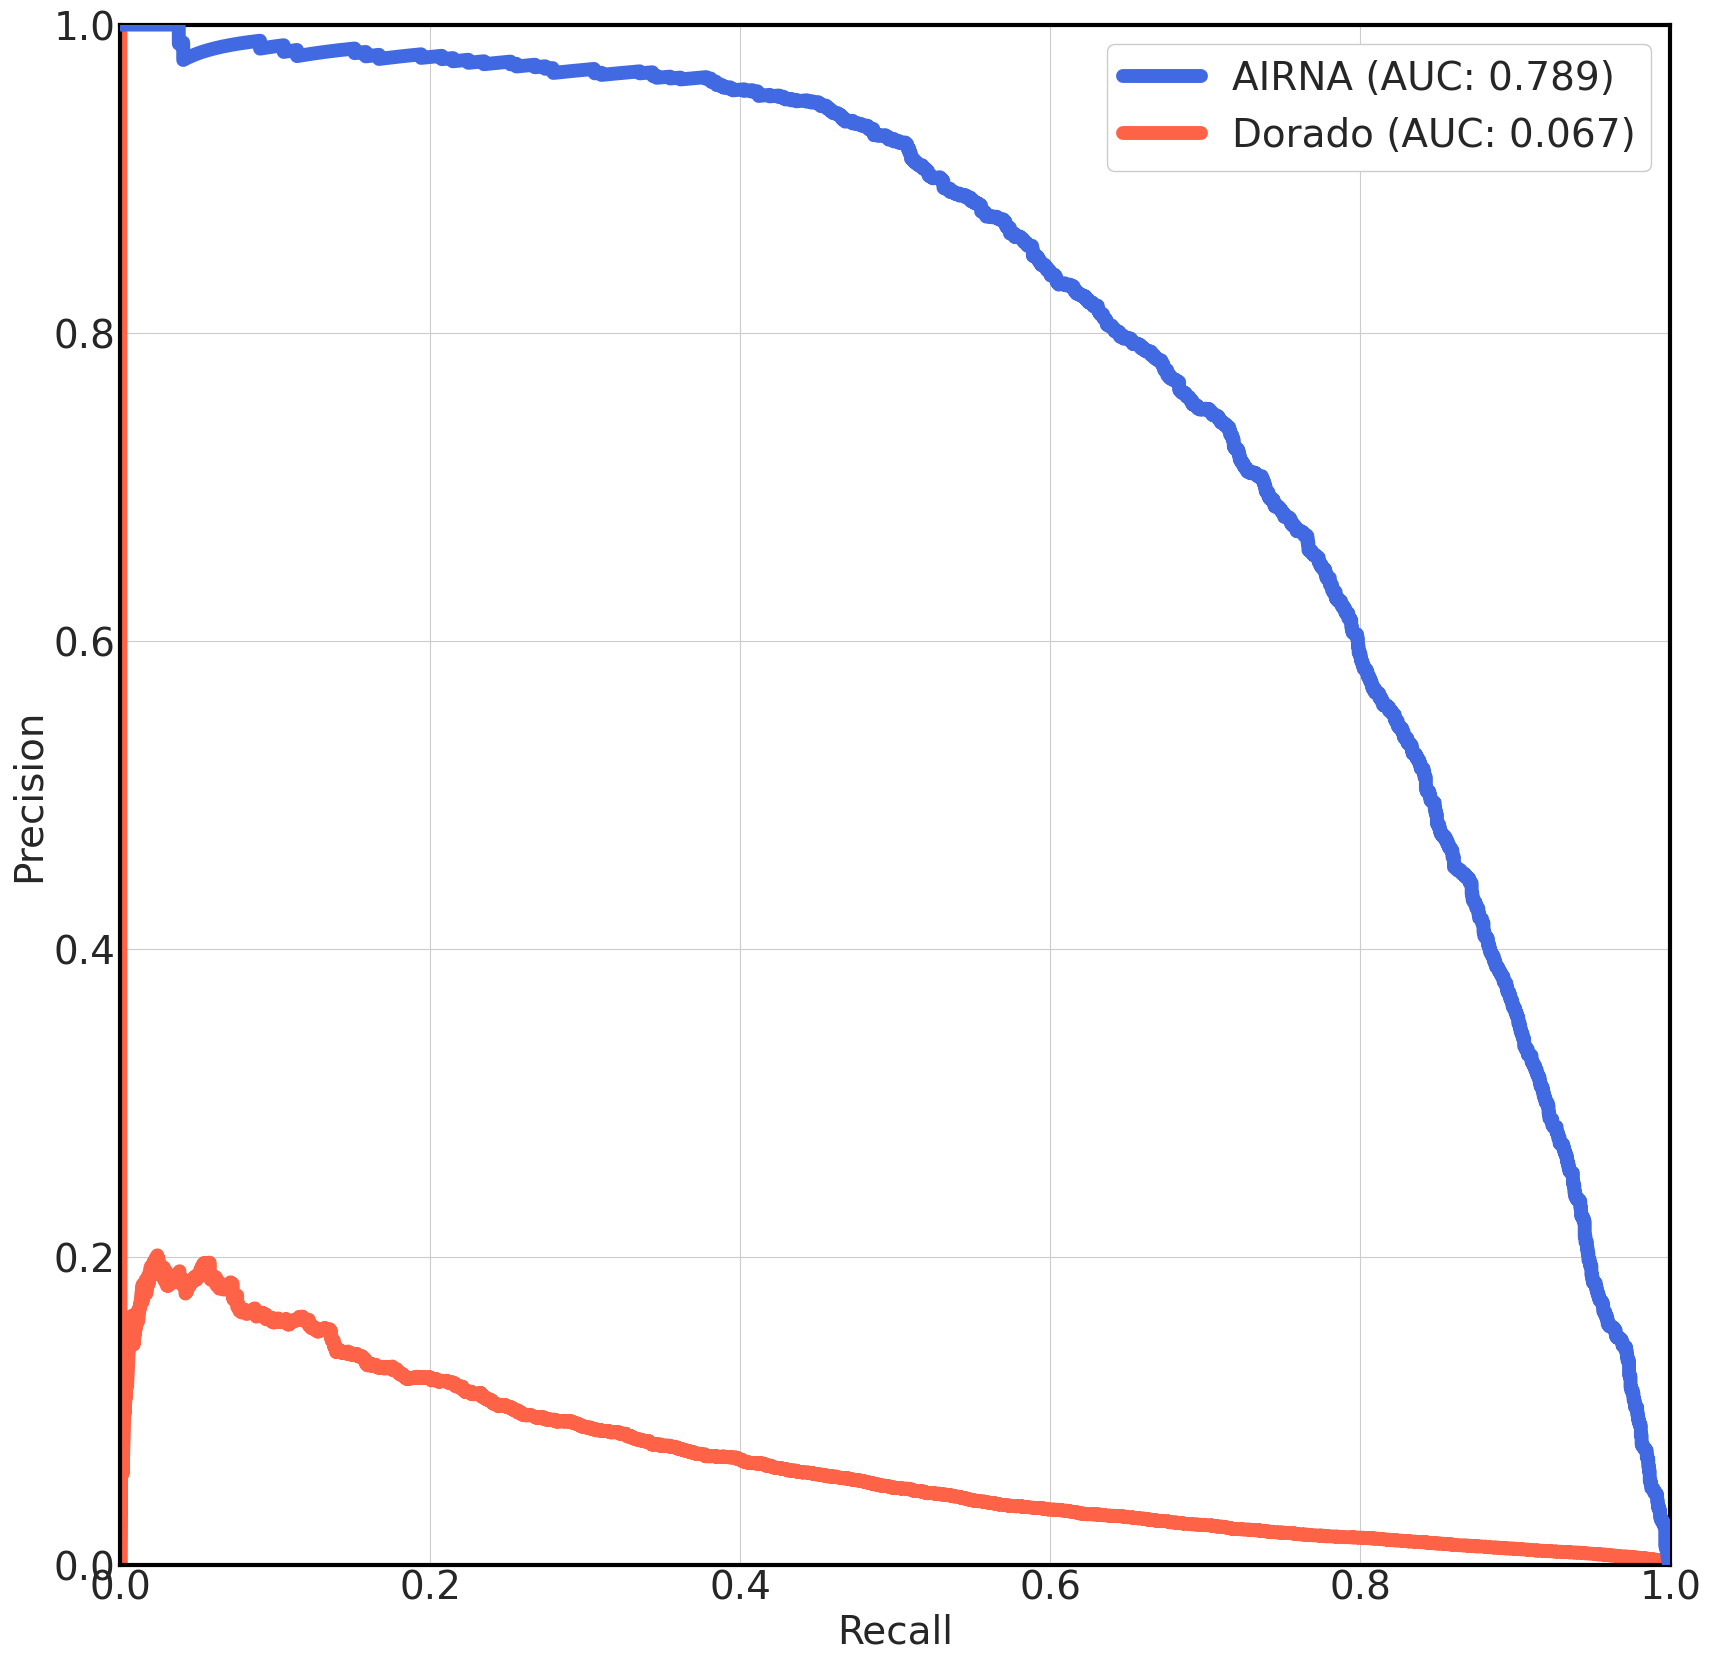

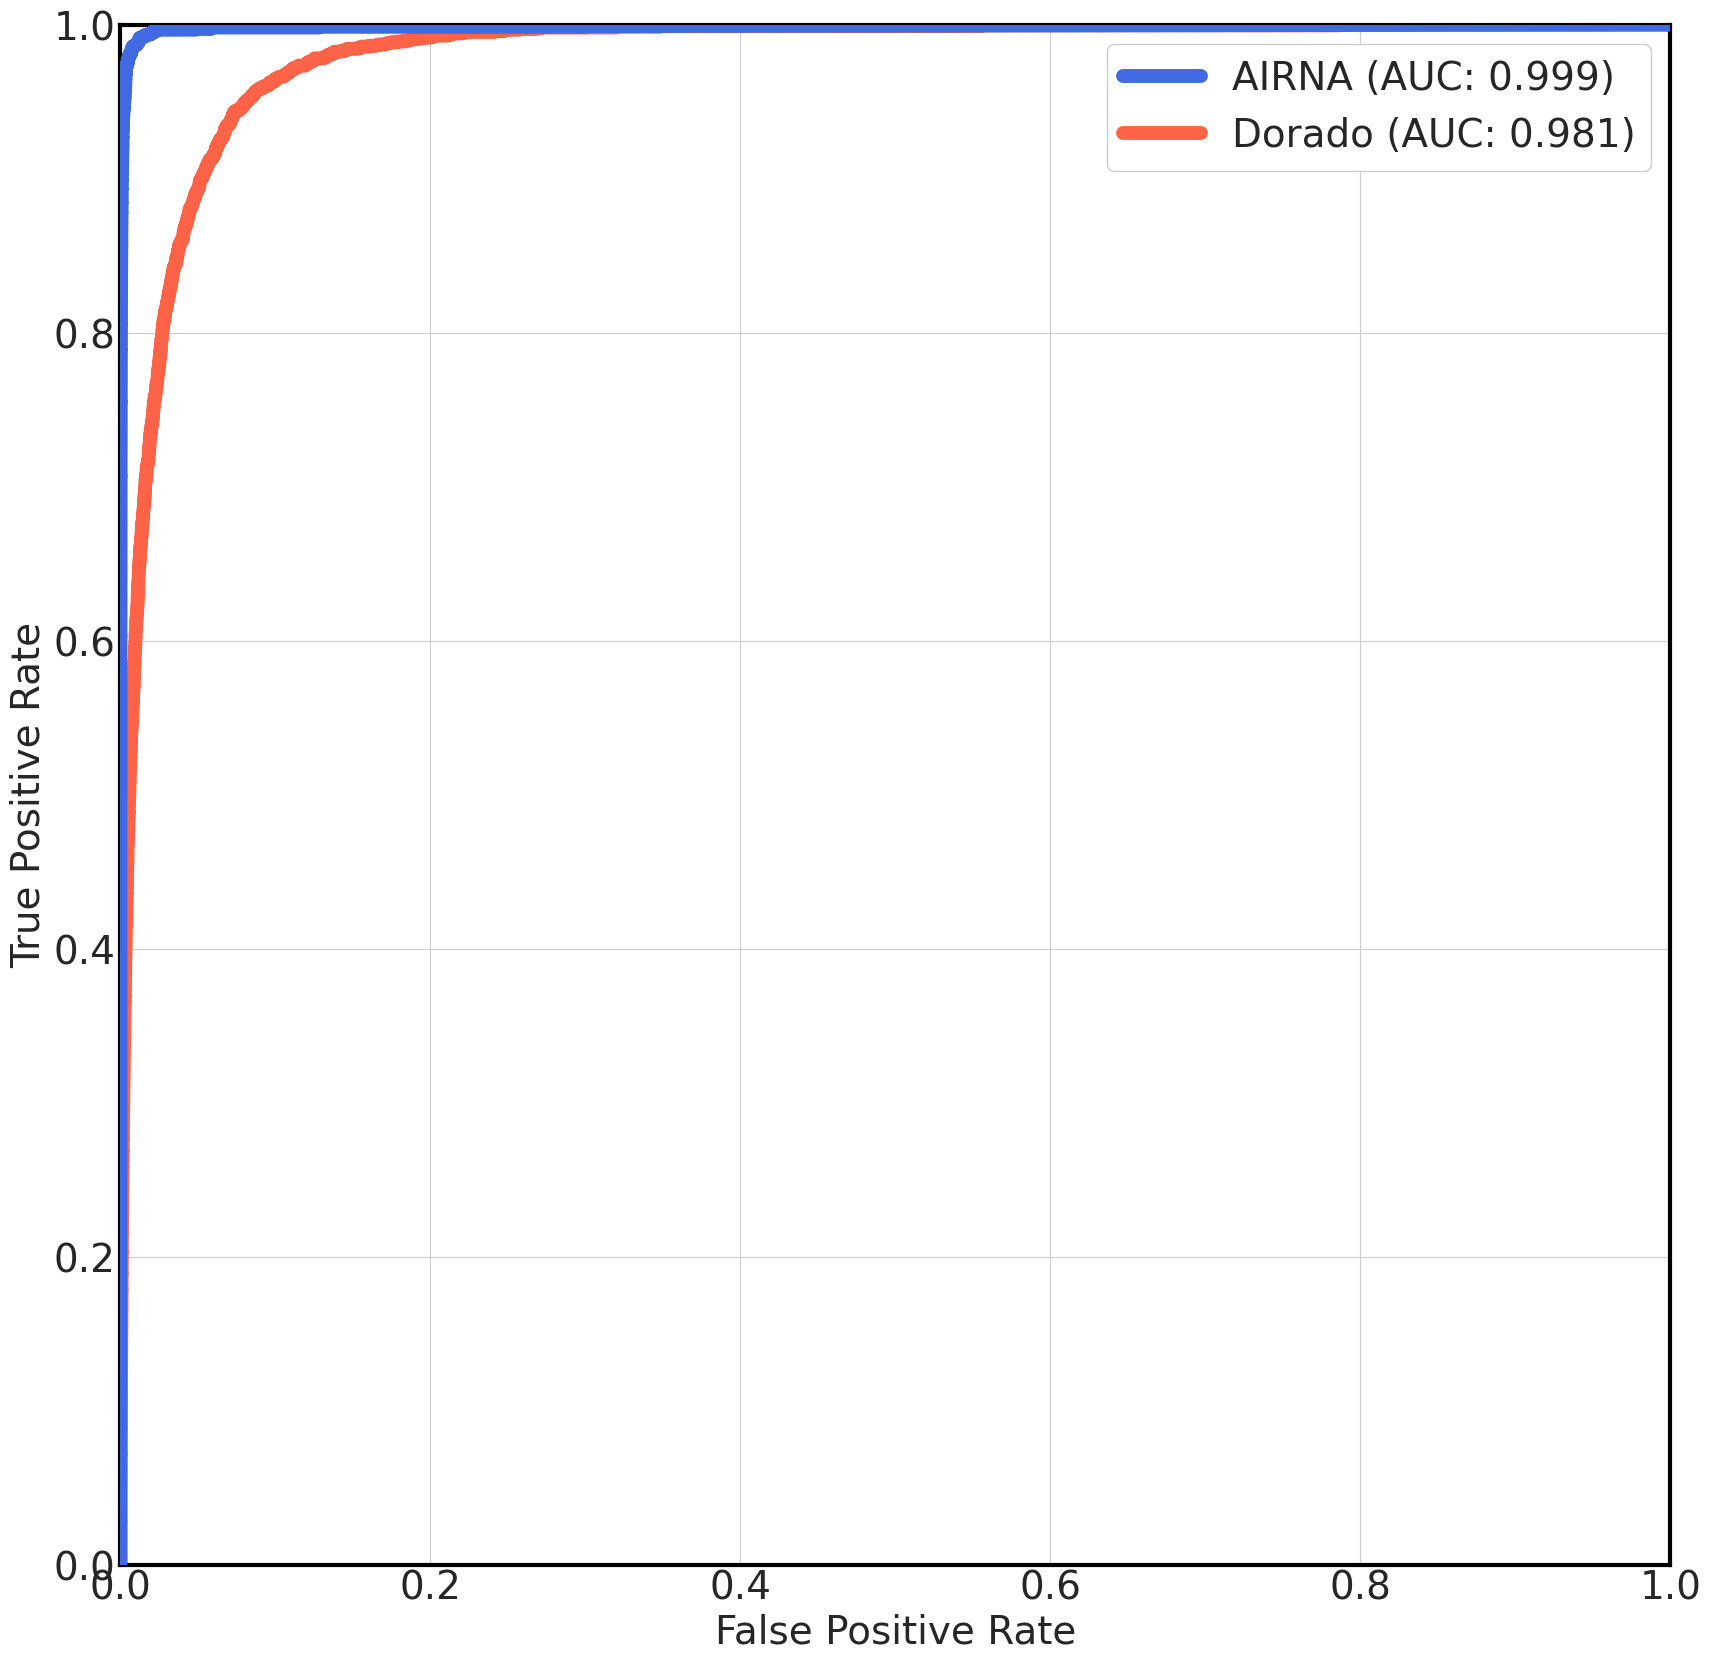

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[~(logsum_alt["drach"]) & ((logsum_alt["depth"] >= 100)) & (logsum_alt["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

print(selected_df)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)


## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/nondrach_roc.pdf", format="pdf")
plt.show()

                genome_id      pm6a       dom  count_all  pred_dorado  \
1         chr10:+:1000683 -0.000000  0.005827      488.0     0.004073   
4         chr10:+:1000701  0.007402  0.007397      486.0     0.002092   
10        chr10:+:1000722  0.039439  0.007679      494.0     0.014463   
30        chr10:+:1000831  0.048103  0.020439      499.0     0.020492   
33        chr10:+:1000842  0.017119  0.018393      496.0     0.008658   
...                   ...       ...       ...        ...          ...   
13247474  chrX:-:85978868  0.189710  0.075965       20.0     0.000000   
13247478  chrX:-:85978880 -0.000000  0.008832       20.0     0.040000   
13247480  chrX:-:85978886  0.000000  0.000000       20.0     0.000000   
13247492  chrX:-:85981763  0.000000  0.000000        0.0     0.000000   
13247496  chrX:-:85981788  0.000000  0.000000       21.0     0.000000   

          dorado_count  pred_m6anet  dom_m6anet  drach  dom_label  label  \
1                491.0     0.114429    0.020225

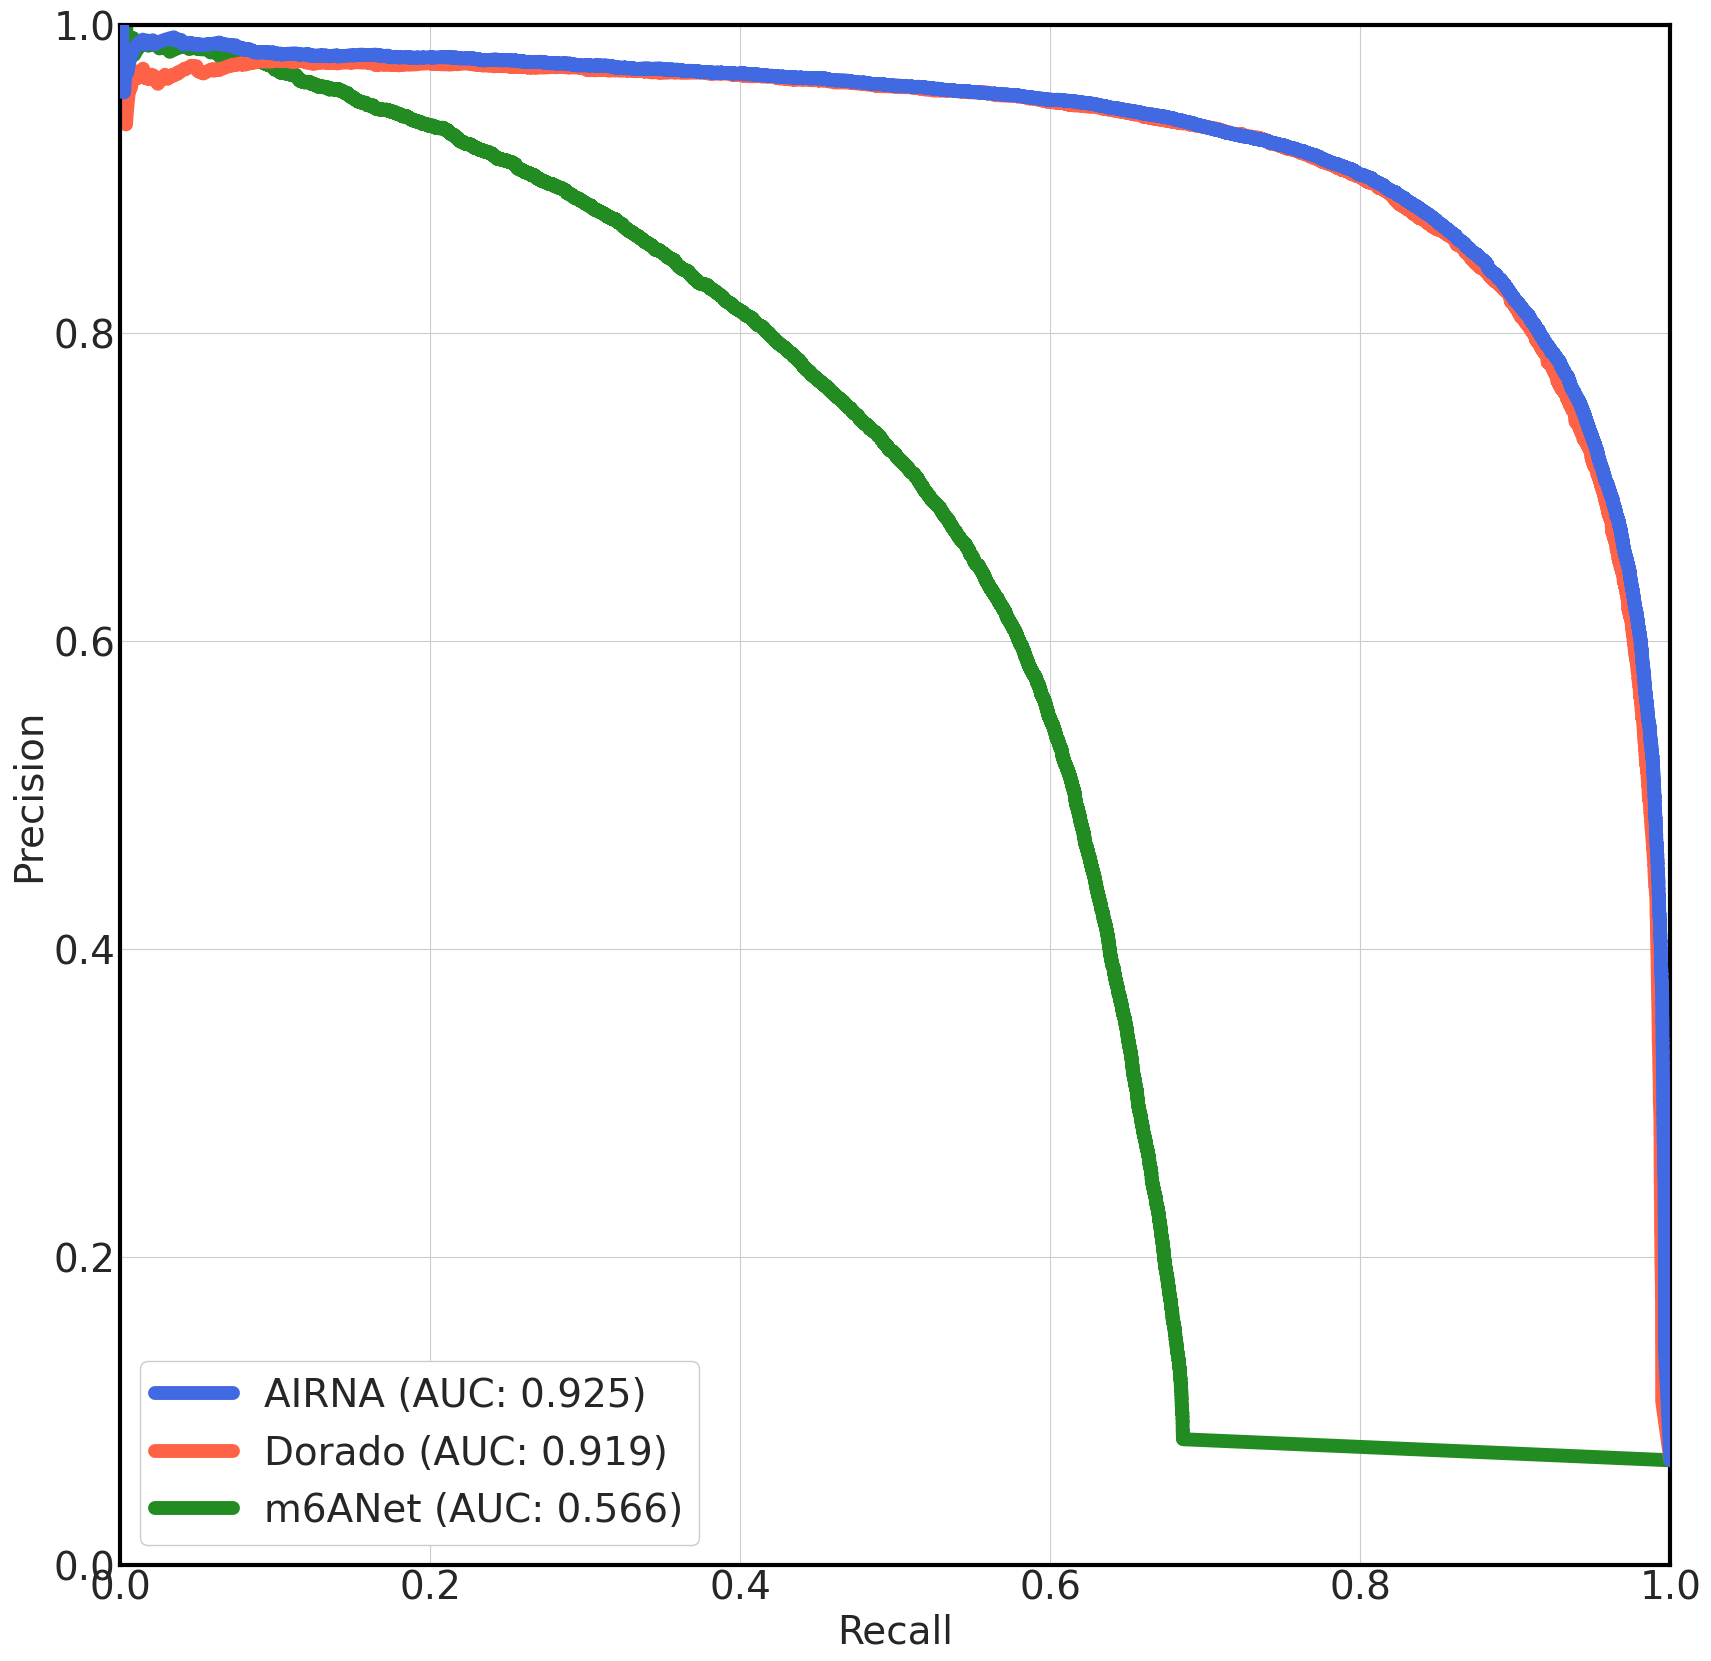

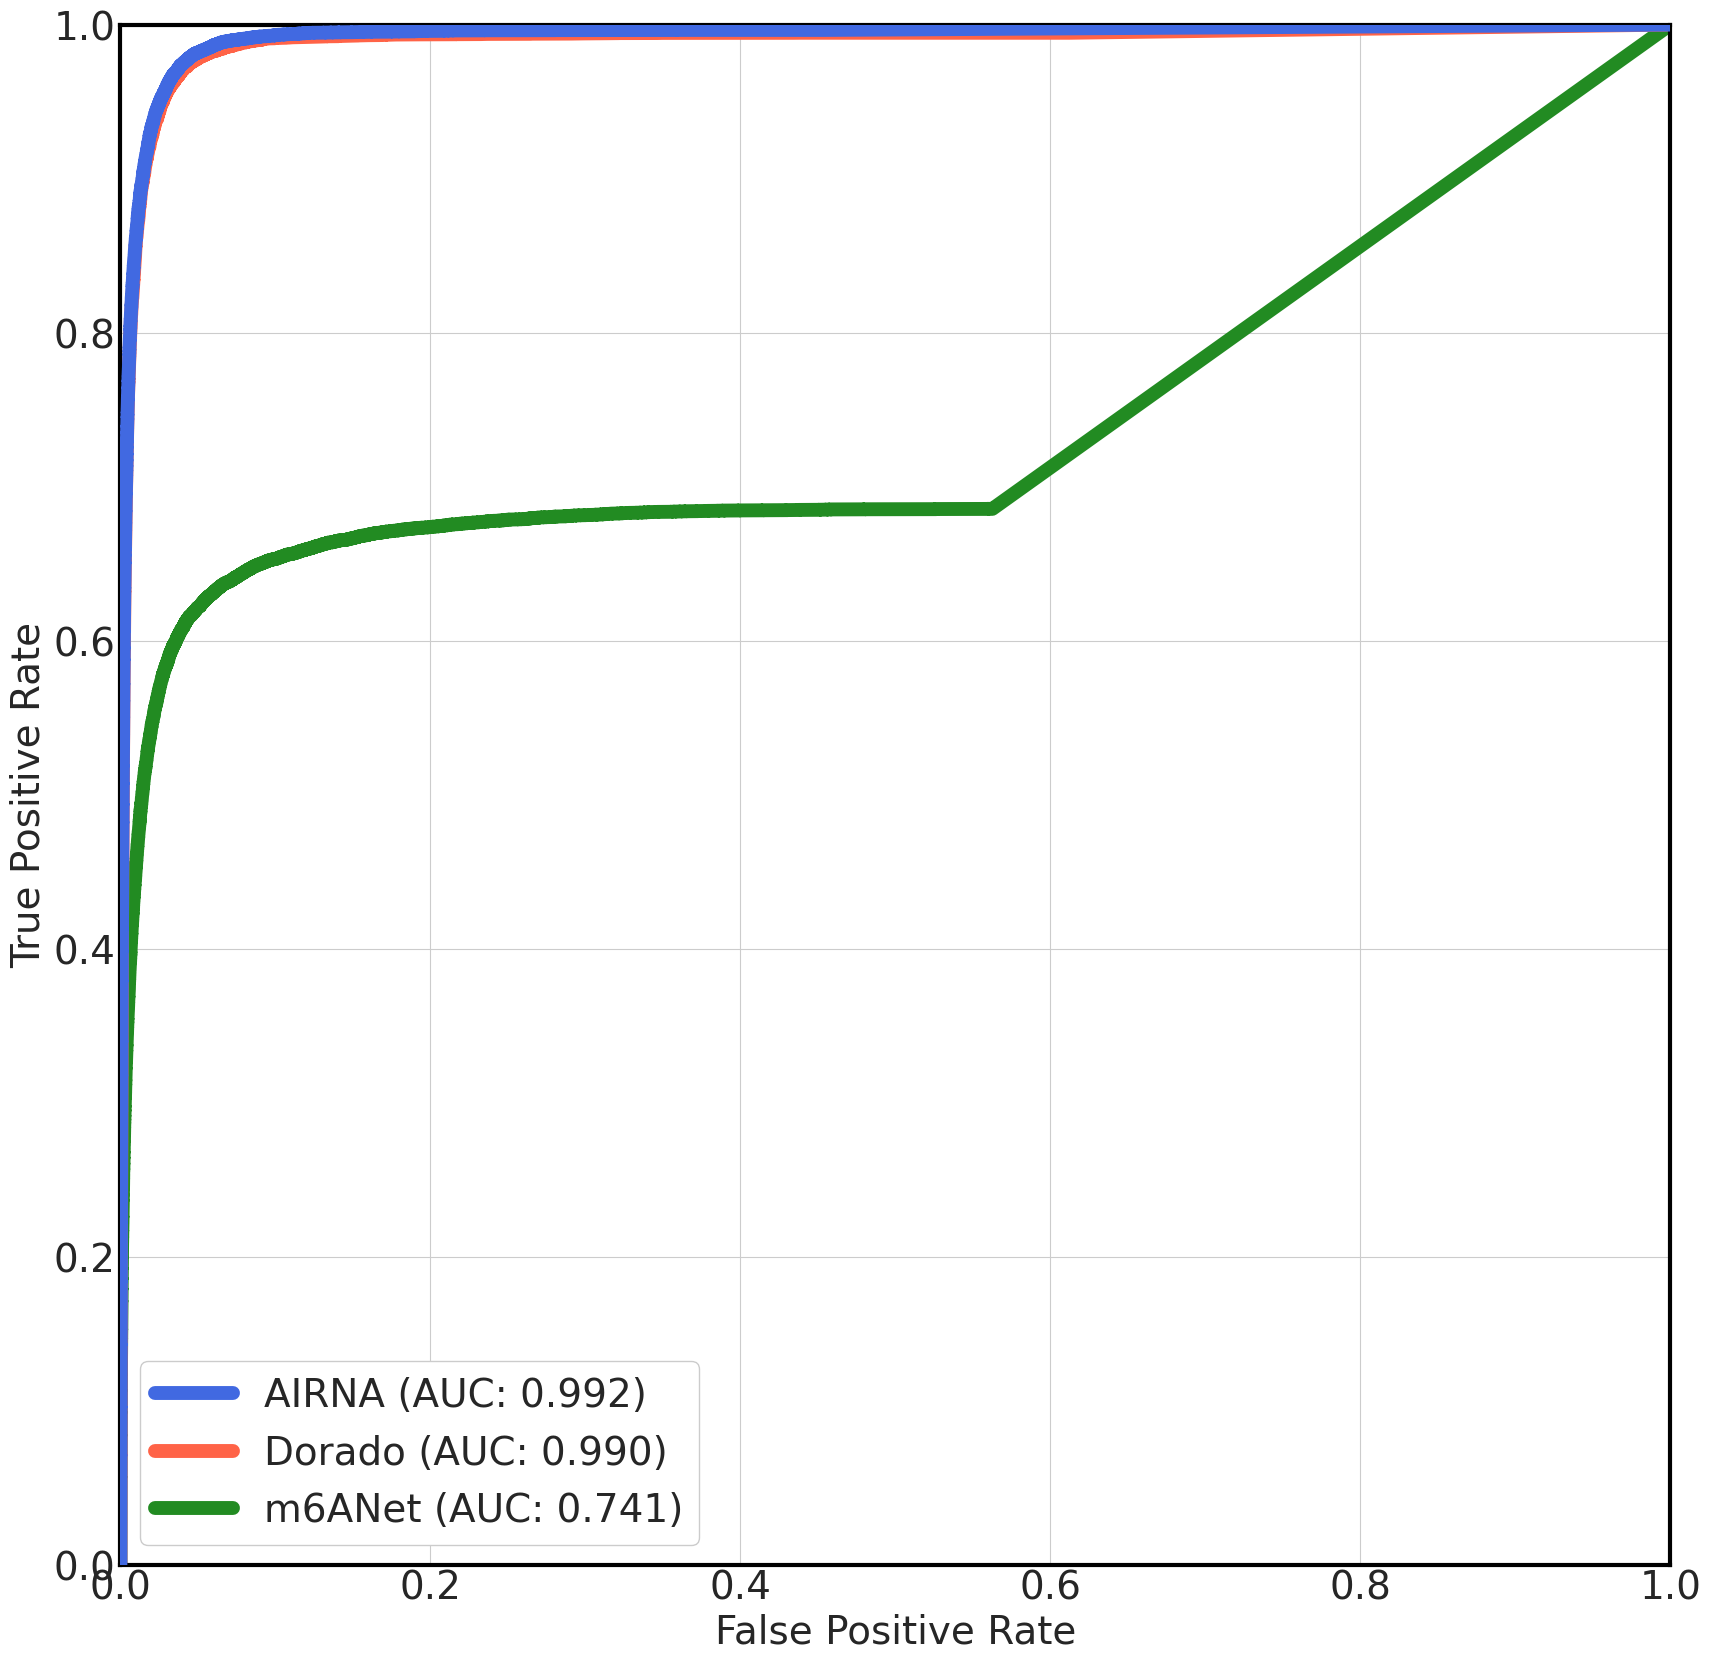

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

selected_df = logsum_alt[(logsum_alt["drach"]) & (logsum_alt["label"] >= 0)& (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

print(selected_df)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_pr.pdf", format="pdf")
plt.show()


## Plot ROC
fig, ax = plt.subplots(1, 1, figsize=(20, 20))

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
auc_score = auc(fpr, tpr)
ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

## Bolder grid outline
for dir in ["top", "right", "left", "bottom"]:
    ax.spines[dir].set_linewidth(3)
    ax.spines[dir].set_color("black")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.legend()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/drach_roc.pdf", format="pdf")
plt.show()


In [23]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}")

AIRNA Max F1: 0.844, Threshold: 0.869
Dorado Max F1: 0.594, Threshold: 0.460
m6Anet Max F1: 0.566, Threshold: 0.612


In [24]:

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
threshold = thresholds[f1_argmax]

print(f"AIRNA Max F1: {max_f1:.3f}, Threshold: {threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")


precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1) 
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"Dorado Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

precision, recall, thresholds = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
f1 = 2 * (precision * recall) / (precision + recall)

f1_argmax = np.argmax(f1)
max_f1 = f1[f1_argmax]
m6anet_threshold = thresholds[f1_argmax]

print(f"m6Anet Max F1: {max_f1:.3f}, Threshold: {m6anet_threshold:.3f}, Recall: {recall[f1_argmax]:.3f}, Precision: {precision[f1_argmax]:.3f}")

AIRNA Max F1: 0.844, Threshold: 0.869, Recall: 0.848, Precision: 0.840
Dorado Max F1: 0.594, Threshold: 0.460, Recall: 0.578, Precision: 0.612
m6Anet Max F1: 0.566, Threshold: 0.612, Recall: 0.494, Precision: 0.662


In [ ]:
from sklearn.metrics import accuracy_score

selected_df = logsum_alt[(logsum_alt["label"] >= 0) & (logsum_alt["depth"] >= 20)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df.fillna(0, inplace=True)

In [22]:
accuracy = accuracy_score(selected_df["label"], selected_df["pm6a"] > 0.869)
ppv = selected_df[selected_df["pm6a"] > 0.869]["label"].mean()
print(f"AIRNA Accuracy: {accuracy:.3f}, PPV: {ppv:.3f}")


AIRNA Accuracy: 0.997, PPV: 0.656


In [21]:
accuracy = accuracy_score(selected_df["label"], selected_df["pred_m6anet"] > 0.566)
ppv = selected_df[selected_df["pred_m6anet"] > 0.566]["label"].mean()
print(f"AIRNA Accuracy: {accuracy:.3f}, PPV: {ppv:.3f}")

AIRNA Accuracy: 0.996, PPV: 0.622
